In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

VIDEO_PATH = "../data/raw/Registro A_2.MOV"
cap = cv2.VideoCapture(VIDEO_PATH)

print("Video abierto:", cap.isOpened())
print("Cantidad de frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS:", cap.get(cv2.CAP_PROP_FPS))
print("Ancho:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Alto:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

ROI_PATH = "../data/reference/roi_A_gray.png"

roi_gray = cv2.imread(ROI_PATH, cv2.IMREAD_GRAYSCALE)

if roi_gray is None:
    raise RuntimeError(f"No se pudo cargar la ROI: {ROI_PATH}")

print("ROI cargada correctamente.")
print("Dimensiones:", roi_gray.shape)

Video abierto: True
Cantidad de frames: 956
FPS: 29.97804954531201
Ancho: 1920
Alto: 1080
ROI cargada correctamente.
Dimensiones: (130, 320)


Se carga el video y la ROI seleccionada en el módulo 1 para aplicarle los métodos de segmentación y observar su funcionamiento. 

Se aplica el método de Otsu para determinar automáticamente un umbral que permita separar la región oscura correspondiente a la pupila del resto de la imagen. Luego se realiza una operación morfológica para eliminar pequeños objetos y suavizar la región segmentada.

Umbral de Otsu: 107.0


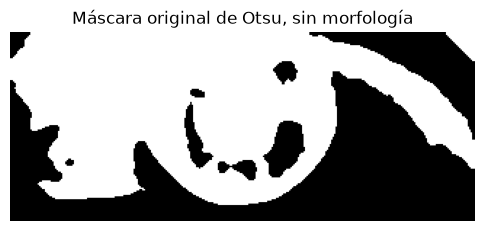

In [44]:
# Otsu sin operaciones morfológicas
blur = cv2.GaussianBlur(roi_gray, (5, 5), sigmaX=2)
threshold, mask_otsu_original = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print("Umbral de Otsu:", threshold)

plt.figure(figsize=(6, 5))
plt.imshow(mask_otsu_original, cmap="gray")
plt.title("Máscara original de Otsu, sin morfología")
plt.axis("off")
plt.show()

Se utiliza el algoritmo K-Means para agrupar los píxeles de la imagen en distintos grupos según sus características de color e intensidad. Se evalúan valores de K entre 2 y 5 para analizar cómo cambia la segmentación de la pupila al aumentar la cantidad de grupos.

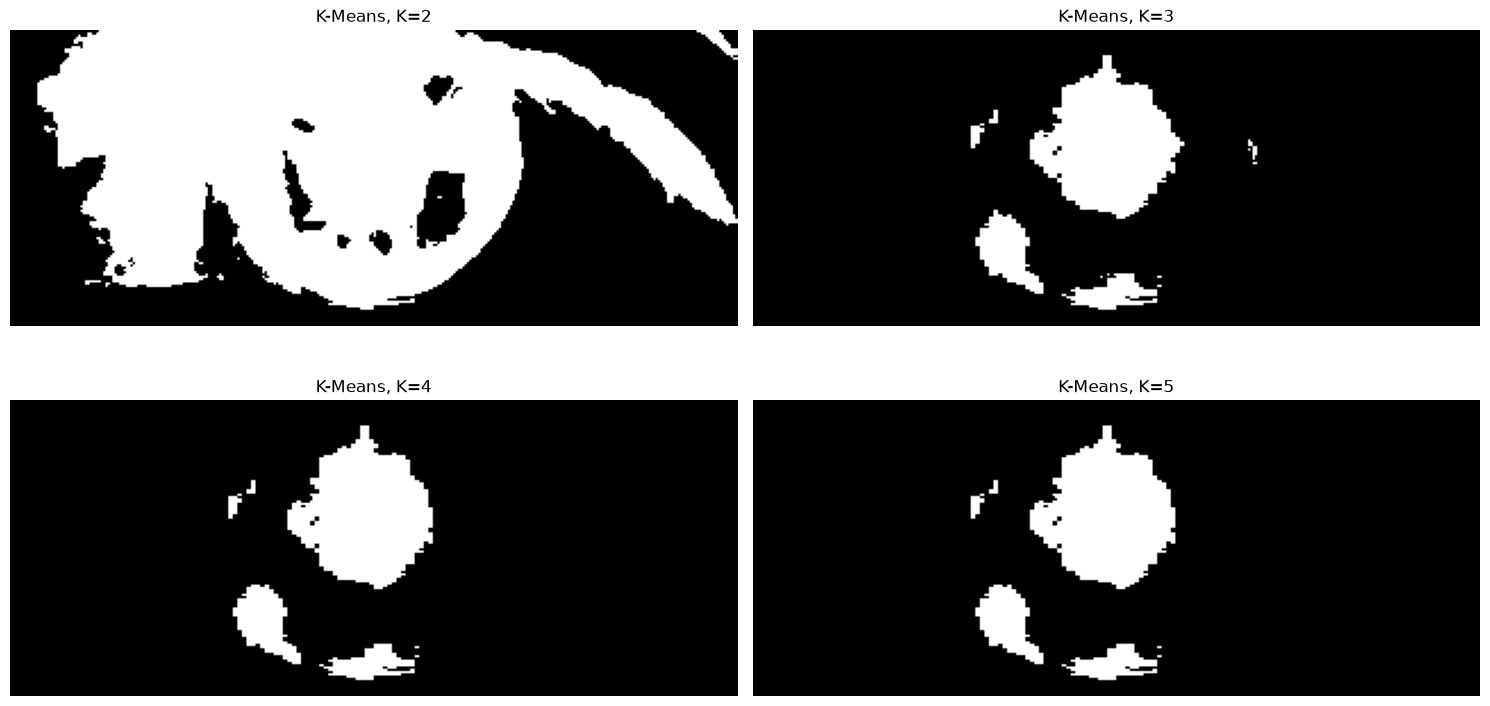

In [45]:
ROI_RGB_PATH = "../data/reference/roi_A_rgb.png"

roi_rgb = cv2.imread(ROI_RGB_PATH)

hsv = cv2.cvtColor(roi_rgb, cv2.COLOR_BGR2HSV)
pixels = hsv.reshape((-1, 3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
results_kmeans = {}

for k in range(2, 6):
    _, labels, centers = cv2.kmeans(pixels,k,None,criteria,10,cv2.KMEANS_PP_CENTERS)

    labels = labels.flatten()
    centers = centers.astype(np.uint8)

    cluster_image = centers[labels]
    cluster_image = cluster_image.reshape(hsv.shape)

    value_image = cluster_image[:, :, 2]

    darkest_cluster = np.argmin(centers[:, 2])

    mask = (labels == darkest_cluster).astype(np.uint8) * 255
    mask = mask.reshape(hsv.shape[:2])

    results_kmeans[k] = mask

plt.figure(figsize=(15, 8))

for i, k in enumerate(range(2, 6)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(results_kmeans[k], cmap="gray")
    plt.title(f"K-Means, K={k}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Usamos un contorno activo para localizar los bordes de la pupila. Definimos manualmente una curva cerrada próxima al borde pupilar y dejamos que evolucione en función de las características de la imagen hasta converger hacia la frontera de la estructura.

In [ ]:
from skimage.segmentation import active_contour
from skimage.filters import gaussian
from skimage.draw import polygon

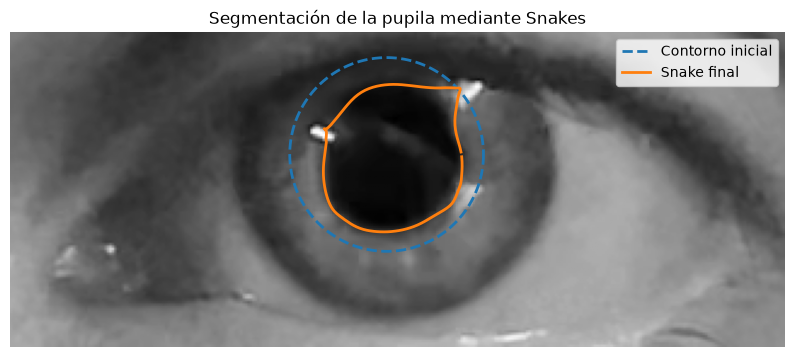

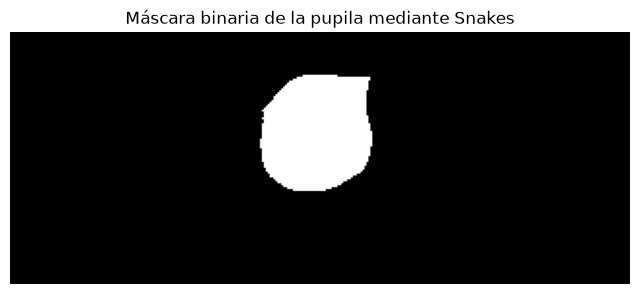

In [95]:
gray_eye = roi_gray.astype(np.float64) / 255.0
smooth_eye = gaussian(gray_eye, sigma=2)

center_x = 155
center_y = 50

# Un poco más grande que la pupila
radius_x = 40
radius_y = 40
theta = np.linspace(0, 2*np.pi, 150)

x = center_x + radius_x * np.cos(theta)
y = center_y + radius_y * np.sin(theta)

init = np.column_stack((y, x))

snake = active_contour(smooth_eye,init,alpha=0.05,beta=0.01,gamma=0.5,w_line=0.1,w_edge=1,max_num_iter=1500,convergence=0.001)

plt.figure(figsize=(10, 7))

plt.imshow(gray_eye, cmap="gray")

plt.plot(
    init[:, 1],
    init[:, 0],
    "--",
    linewidth=2,
    label="Contorno inicial"
)

plt.plot(
    snake[:, 1],
    snake[:, 0],
    linewidth=2,
    label="Snake final"
)

plt.title("Segmentación de la pupila mediante Snakes")
plt.legend()
plt.axis("off")
plt.show()

# Crear una máscara inicialmente negra
mask_snake = np.zeros(gray_eye.shape, dtype=np.uint8)

# Coordenadas del contorno: filas (y) y columnas (x)
rr, cc = polygon(
    snake[:, 0],
    snake[:, 1],
    shape=gray_eye.shape
)

# Rellenar el interior del contorno
mask_snake[rr, cc] = 1

# Visualizar la máscara binaria
plt.figure(figsize=(8, 6))
plt.imshow(mask_snake, cmap="gray", vmin=0, vmax=1)
plt.title("Máscara binaria de la pupila mediante Snakes")
plt.axis("off")
plt.show()

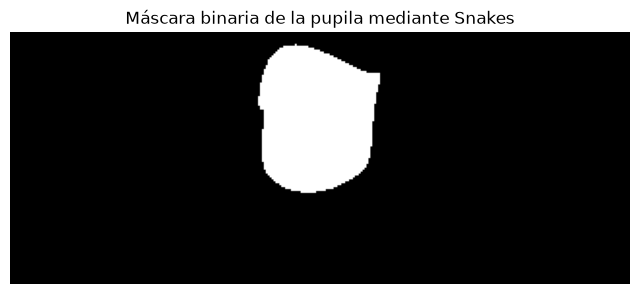

Antes de aplicar Watershed, primero calculamos el gradiente de la imagen y definimos marcadores de regiones. 

Decidimos aumentar el contraste de la imagen porque no se observaba bien el cambio entre el iris y la pupila ya a simple vista. 

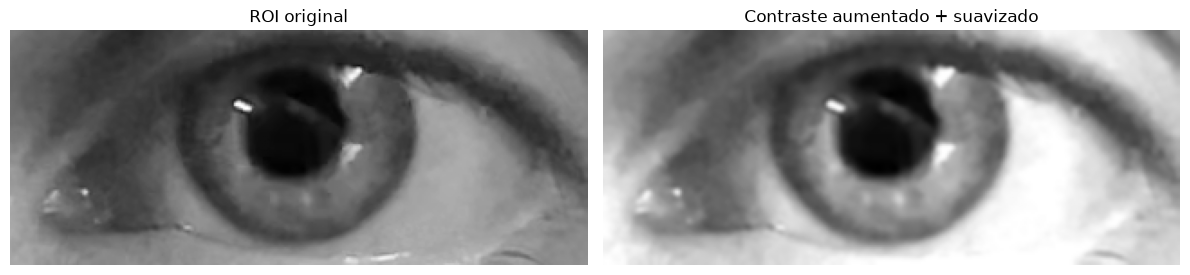

In [48]:
roi_contraste = np.clip(
    roi_gray.astype(np.float32) * 1.5,
    0,
    255
).astype(np.uint8)

roi_suavizada = cv2.GaussianBlur(
    roi_contraste,
    (5, 5),
    0
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(roi_suavizada, cmap="gray")
plt.title("Contraste aumentado + suavizado")
plt.axis("off")

plt.tight_layout()
plt.show()

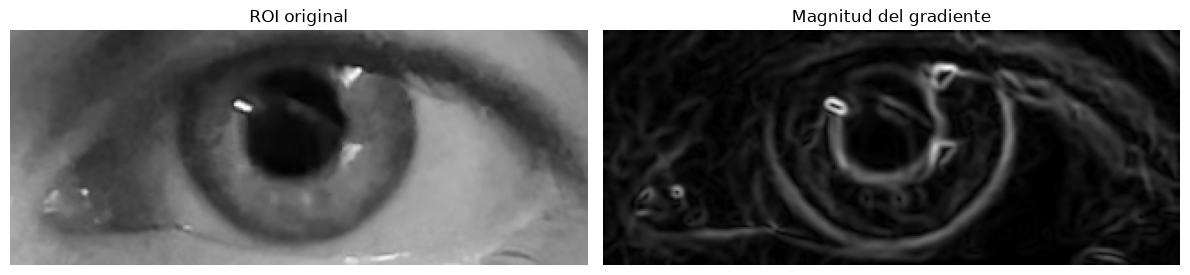

In [49]:
# Gradiente horizontal y vertical
grad_x = cv2.Sobel(
    roi_suavizada,
    cv2.CV_64F,
    1, 0,
    ksize=7
)

grad_y = cv2.Sobel(
    roi_suavizada,
    cv2.CV_64F,
    0, 1,
    ksize=7
)

# Magnitud del gradiente
gradiente = cv2.magnitude(
    grad_x.astype(np.float32),
    grad_y.astype(np.float32)
)

# Normalización para visualizar
gradiente_norm = cv2.normalize(
    gradiente,
    None,
    0, 255,
    cv2.NORM_MINMAX
).astype(np.uint8)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gradiente_norm, cmap="gray")
plt.title("Magnitud del gradiente")
plt.axis("off")

plt.tight_layout()
plt.show()

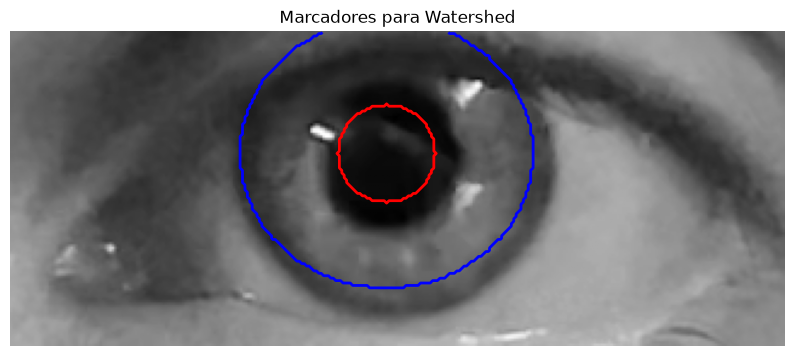

In [50]:
markers = np.zeros(roi_gray.shape, dtype=np.int32)

# Región pequeña dentro de la pupila
cv2.circle(
    markers,
    (int(center_x), int(center_y)),
    20,
    1,
    -1
)

# Todo lo que esté fuera de esta elipse
# se considera background seguro.
roi_mask = np.zeros(roi_gray.shape, dtype=np.uint8)

cv2.ellipse(
    roi_mask,
    (int(center_x), int(center_y)),
    (60, 55),
    0,
    0,
    360,
    1,
    -1
)

# Background seguro = fuera de la elipse
markers[roi_mask == 0] = 2

plt.figure(figsize=(10, 7))

plt.imshow(roi_gray, cmap="gray")

plt.contour(
    markers == 1,
    colors="r",
    linewidths=2
)

plt.contour(
    markers == 2,
    colors="b",
    linewidths=2
)

plt.title("Marcadores para Watershed")
plt.axis("off")
plt.show()

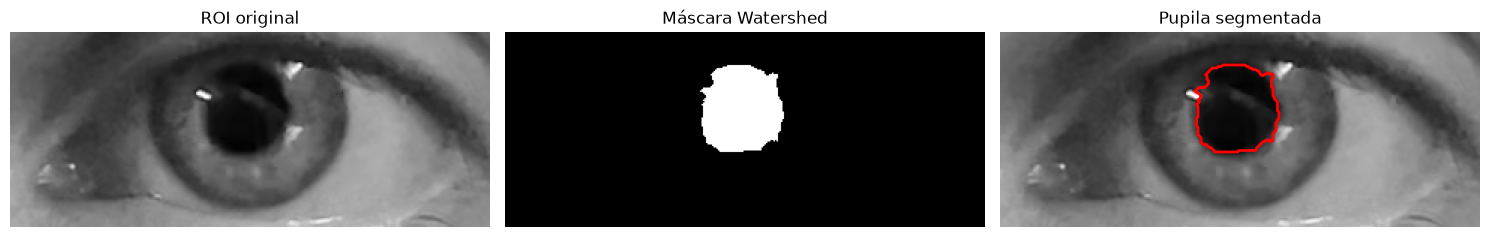

In [51]:
roi_bgr = cv2.cvtColor(
    roi_suavizada,
    cv2.COLOR_GRAY2BGR
)

markers_ws = cv2.watershed(
    roi_bgr,
    markers.copy()
)

mask_watershed = (markers_ws == 1).astype(np.uint8) * 255

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(roi_gray, cmap="gray")
plt.title("ROI original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_watershed, cmap="gray")
plt.title("Máscara Watershed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(roi_gray, cmap="gray")
plt.contour(
    mask_watershed > 0,
    colors="r",
    linewidths=2
)
plt.title("Pupila segmentada")
plt.axis("off")

plt.tight_layout()
plt.show()

Con el método de Watershed, se obtiene un contorno bastante cercano al de la pupila pero irregular. 

Ahora aplicamos erosión, dilatación, apertura y cierre sobre la máscara de Otsu para eliminar destellos luminosos. Las propiedades morfológicas se utilizan para remover imperfecciones de la imagen segmentada para luego obtener información de la estructura y forma de los objetos.
Si bien watershed segmenta mejor la pupila, no se visualiza bien la eliminación de destellos luminosos (reflejos corneales del flash), oclusión por pestañas o sombras que pide la consigna si utilizamos dicha máscara para aplicar las operaciones.

El kernel determina el tamaño del kernel del elemento estructurante que se utiliza en cada operación. Un kernel demasiado grande puede borrar partes de la pupila o alterar su forma, por lo que empezamos con uno pequeño (3x3)

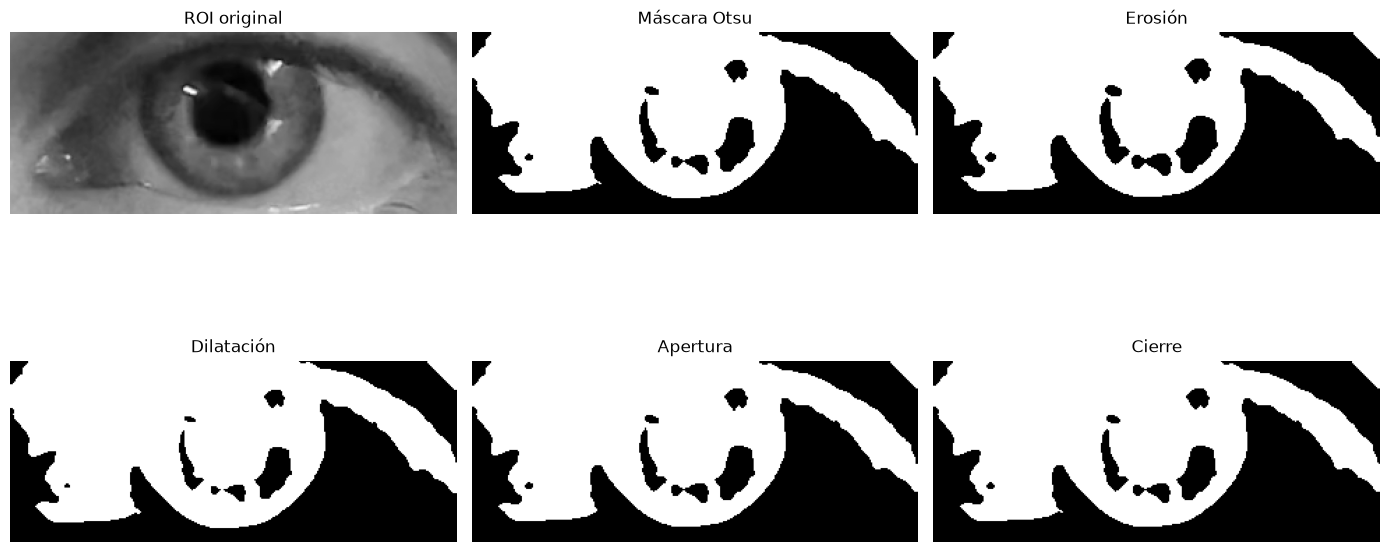

In [52]:
# Usamos directamente la máscara que ya tenemos de Otsu, sin operaciones morfológicas
kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

# Aplicar operaciones morfológicas
mask_erosion = cv2.erode(mask_otsu_original, kernel, iterations=1)

mask_dilatacion = cv2.dilate(mask_otsu_original, kernel, iterations=1)

mask_apertura = cv2.morphologyEx(mask_otsu_original, cv2.MORPH_OPEN, kernel)

mask_cierre = cv2.morphologyEx(mask_otsu_original, cv2.MORPH_CLOSE, kernel)

resultados = {
    "ROI original": roi_gray,
    "Máscara Otsu": mask_otsu_original,
    "Erosión": mask_erosion,
    "Dilatación": mask_dilatacion,
    "Apertura": mask_apertura,
    "Cierre": mask_cierre
}

plt.figure(figsize=(14, 8))

for i, (nombre, mascara) in enumerate(resultados.items()):
    plt.subplot(2, 3, i + 1)
    plt.imshow(mascara, cmap="gray")
    plt.title(nombre)
    plt.axis("off")

plt.tight_layout()
plt.show()

Luego, genero la esqueletización, donde me quedo con la estructura mínima que conserva la forma del objeto original. Pretende obtener de la imagen un patrón continuo que contenga la menor cantidad de datos posibles, pero que siga aún, conteniendo un rastro del objeto original

La genero primero con el algoritmo de Otsu como base

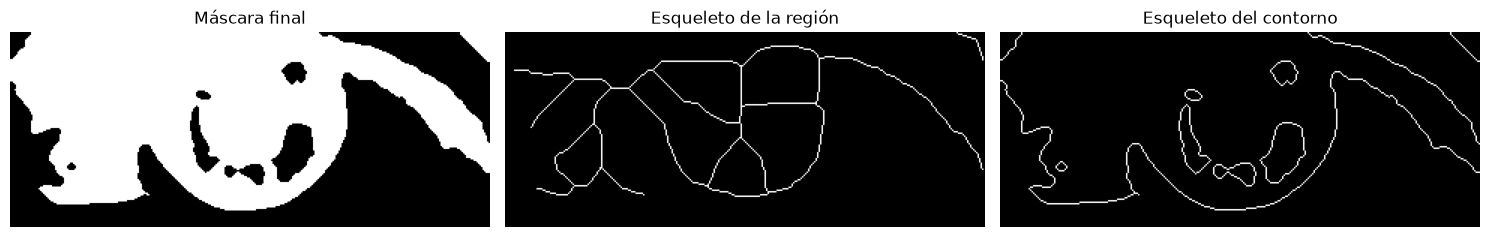

In [53]:
from skimage.morphology import skeletonize

# Elegimos la máscara final que queremos analizar, en este caso la de cierre
mask_final = mask_cierre

# Convertimos la máscara a booleanos para usar skeletonize
mask_bool = mask_final > 0

# Esqueleto de la región pupilar
esqueleto_region = skeletonize(mask_bool)

# Extraer el borde mediante la diferencia entre la máscara y su versión erosionada
mask_erosion_borde = cv2.erode(
    mask_final,
    kernel,
    iterations=1
)

contorno_binario = (mask_final > 0) & (mask_erosion_borde == 0)

# Esqueleto del contorno extraído
esqueleto_contorno = skeletonize(contorno_binario)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_final, cmap="gray")
plt.title("Máscara final")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(esqueleto_region, cmap="gray")
plt.title("Esqueleto de la región")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(esqueleto_contorno, cmap="gray")
plt.title("Esqueleto del contorno")
plt.axis("off")

plt.tight_layout()
plt.show()

Después genero el esqueleto a partir del algoritmo de watershed para comparar. Este es mucho más preciso para la segmentación de la pupila.

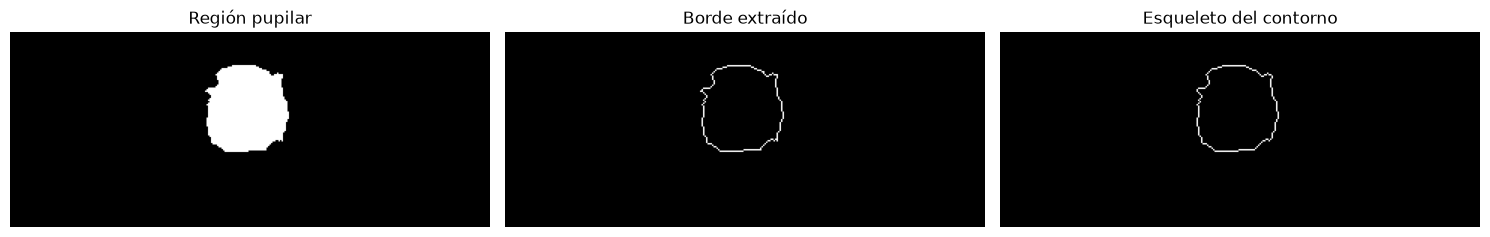

In [60]:
# Extraer los contornos externos de la región pupilar
contornos, _ = cv2.findContours(
    mask_watershed.copy(),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

# Dibujar el contorno sobre la ROI original
imagen_contorno = cv2.cvtColor(
    roi_gray,
    cv2.COLOR_GRAY2RGB
)

# Crear un borde fino a partir de la máscara de Watershed
kernel_borde = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (3, 3)
)

borde_pupila = cv2.subtract(
    mask_watershed,
    cv2.erode(mask_watershed, kernel_borde)
)

# Esqueletizar el borde extraído
esqueleto_contorno = skeletonize(borde_pupila > 0)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(mask_watershed, cmap="gray")
plt.title("Región pupilar")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(borde_pupila, cmap="gray")
plt.title("Borde extraído")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(esqueleto_contorno, cmap="gray")
plt.title("Esqueleto del contorno")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Otsu: usar la máscara SIN operaciones morfológicas previas
mascara_otsu = mask_otsu_original.copy()
# K-Means: incluir los resultados con K = 2, 3, 4 y 5
mascaras_kmeans = {
    f"K-Means K={k}": mascara.copy()
    for k, mascara in results_kmeans.items()
}

# Snakes: convertir el contorno del snake en una máscara rellena
# snake tiene coordenadas (fila, columna), es decir, (y, x)
mascara_snakes = np.zeros(roi_gray.shape, dtype=np.uint8)

puntos_snake = np.round(
    np.column_stack((snake[:, 1], snake[:, 0]))
).astype(np.int32)

cv2.fillPoly(
    mascara_snakes,
    [puntos_snake],
    255
)

# Watershed: máscara de la región segmentada
mascara_watershed = mask_watershed.copy()

# Reunir todas las máscaras en un único diccionario
mascaras_originales = {
    "Otsu": mascara_otsu,
    **mascaras_kmeans,
    "Snakes": mascara_snakes,
    "Watershed": mascara_watershed
}

# Comprobar dimensiones y binarizar las máscaras
for nombre, mascara in mascaras_originales.items():
    if mascara.shape != roi_gray.shape:
        raise ValueError(
            f"{nombre}: la máscara no tiene las dimensiones de la ROI."
        )

    mascaras_originales[nombre] = (
        mascara > 0
    ).astype(np.uint8) * 255

print("Máscaras originales preparadas:")
for nombre, mascara in mascaras_originales.items():
    print(f"{nombre}: {mascara.shape}")

Máscaras originales preparadas:
Otsu: (130, 320)
K-Means K=2: (130, 320)
K-Means K=3: (130, 320)
K-Means K=4: (130, 320)
K-Means K=5: (130, 320)
Snakes: (130, 320)
Watershed: (130, 320)


In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3, 3))

mascaras_comparacion = {}

for nombre, mascara in mascaras_originales.items():
    # Guardar el resultado original
    mascaras_comparacion[f"{nombre} - Original"] = mascara.copy()
    # Erosión
    mascaras_comparacion[f"{nombre} - Erosión"] = cv2.erode(mascara, kernel, iterations=1)
    # Dilatación
    mascaras_comparacion[f"{nombre} - Dilatación"] = cv2.dilate(mascara, kernel, iterations=1)
    # Apertura
    mascaras_comparacion[f"{nombre} - Apertura"] = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    # Cierre
    mascaras_comparacion[f"{nombre} - Cierre"] = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel)
    # Apertura seguida de cierre
    mascara_apertura = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara_apertura_cierre = cv2.morphologyEx(mascara_apertura, cv2.MORPH_CLOSE, kernel)
    mascaras_comparacion[
        f"{nombre} - Apertura + Cierre"
    ] = mascara_apertura_cierre

Cantidad total de máscaras: 42


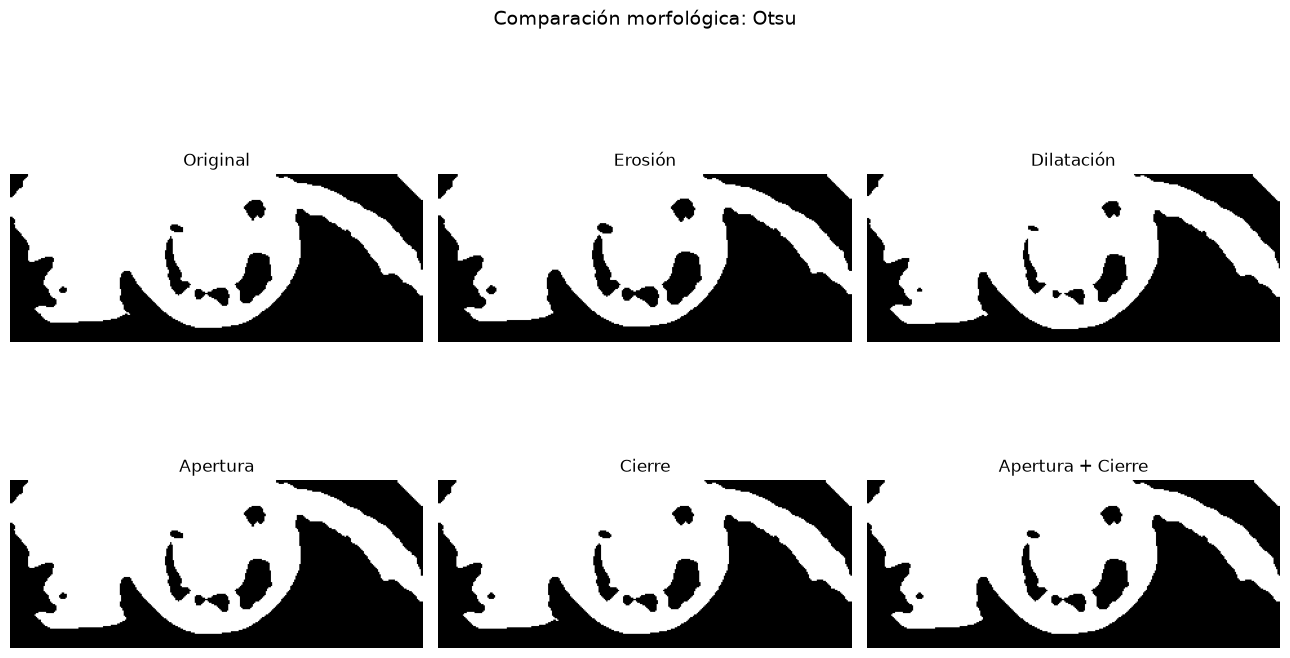

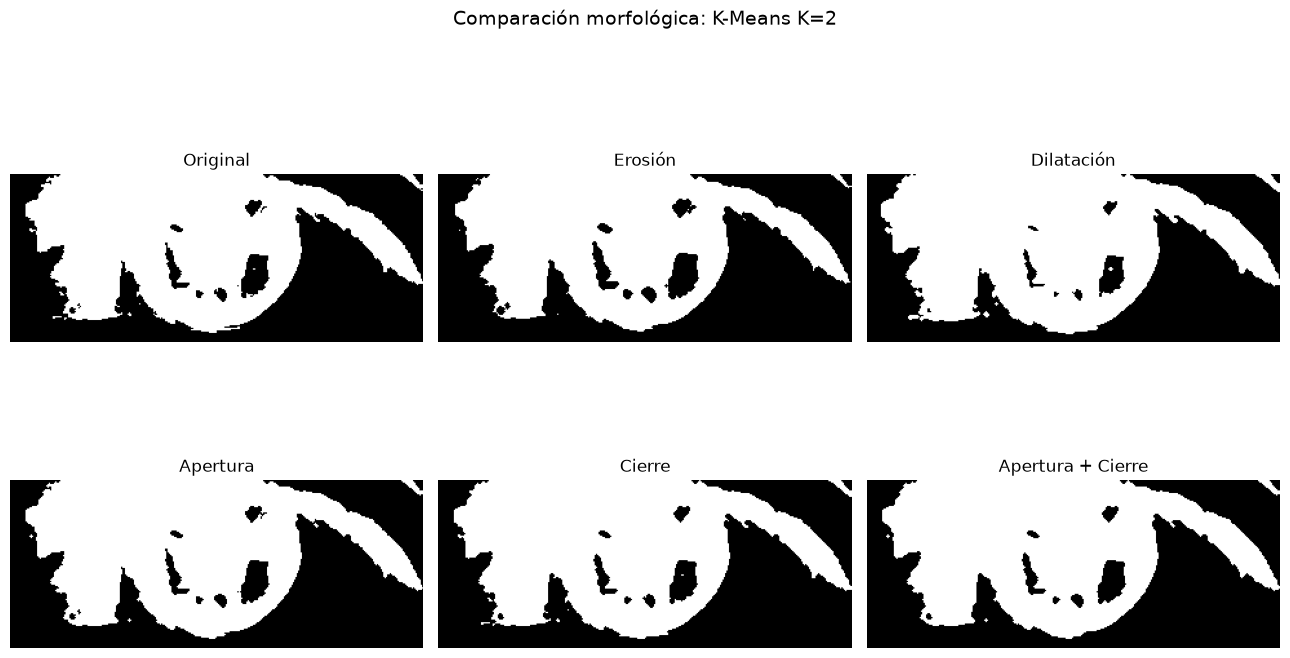

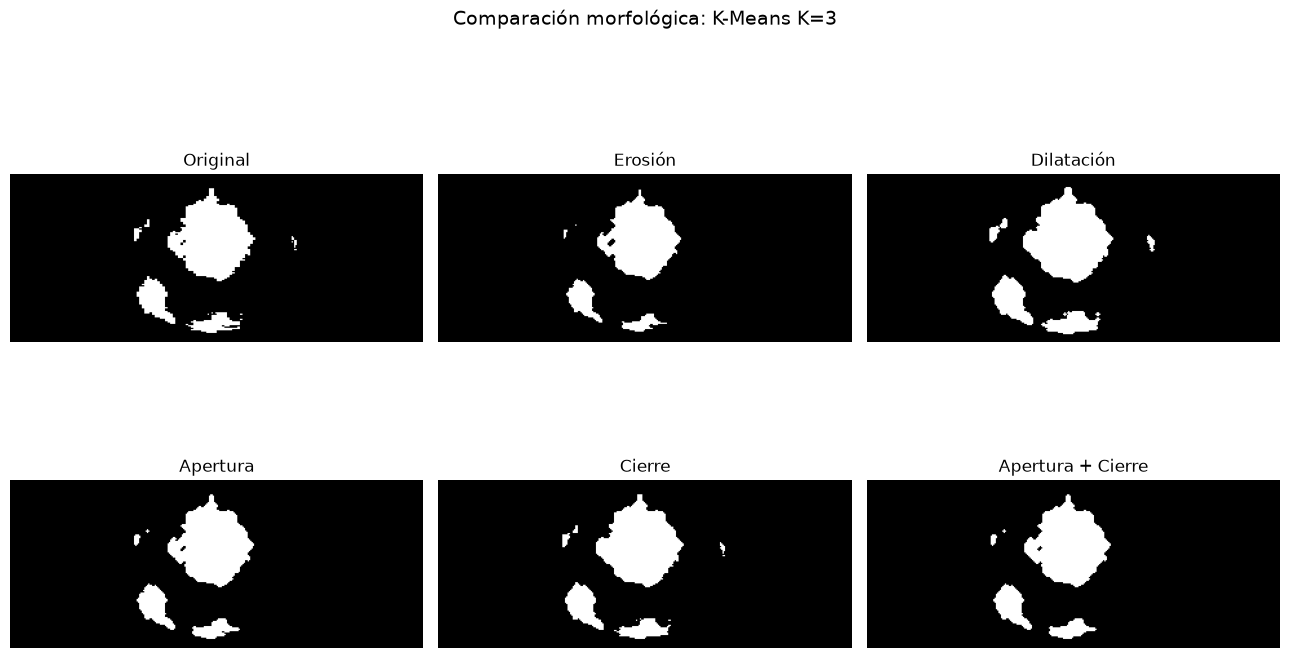

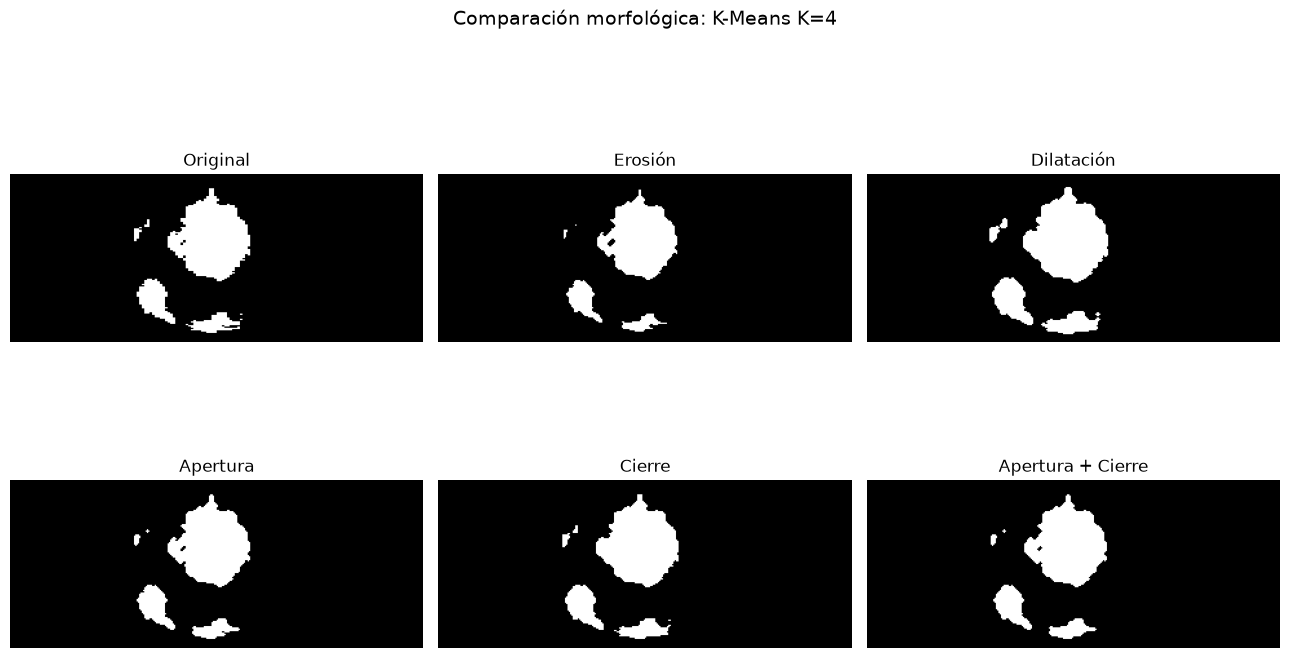

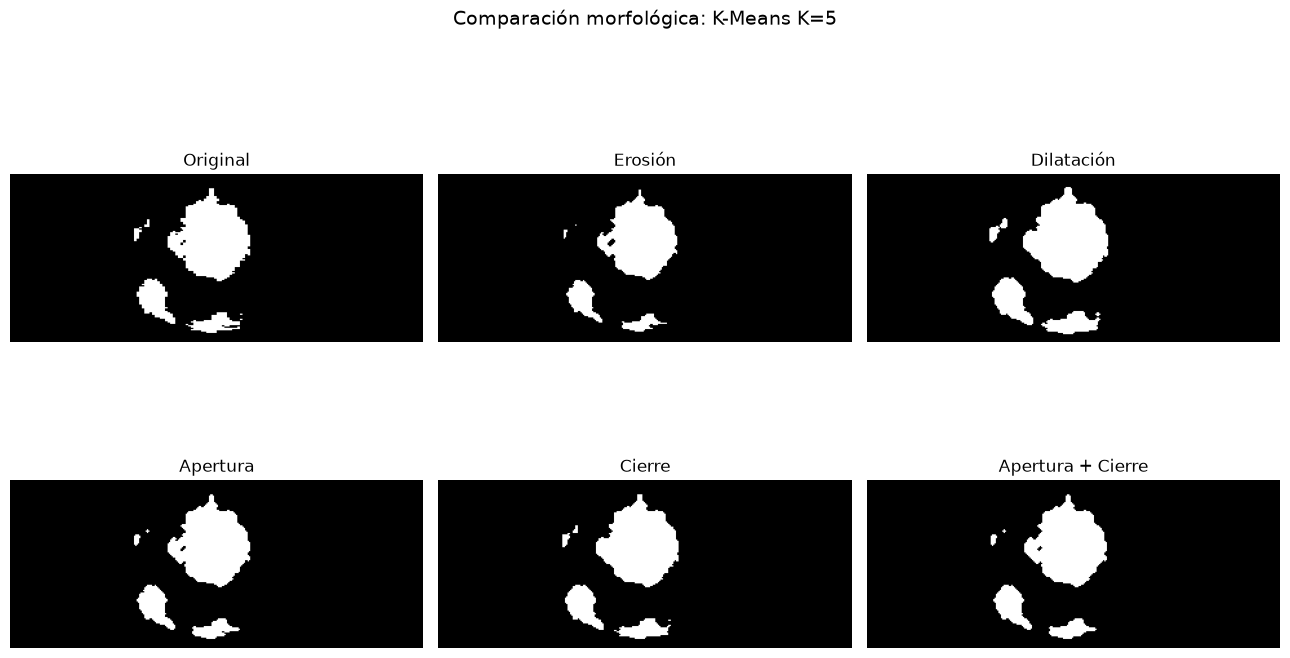

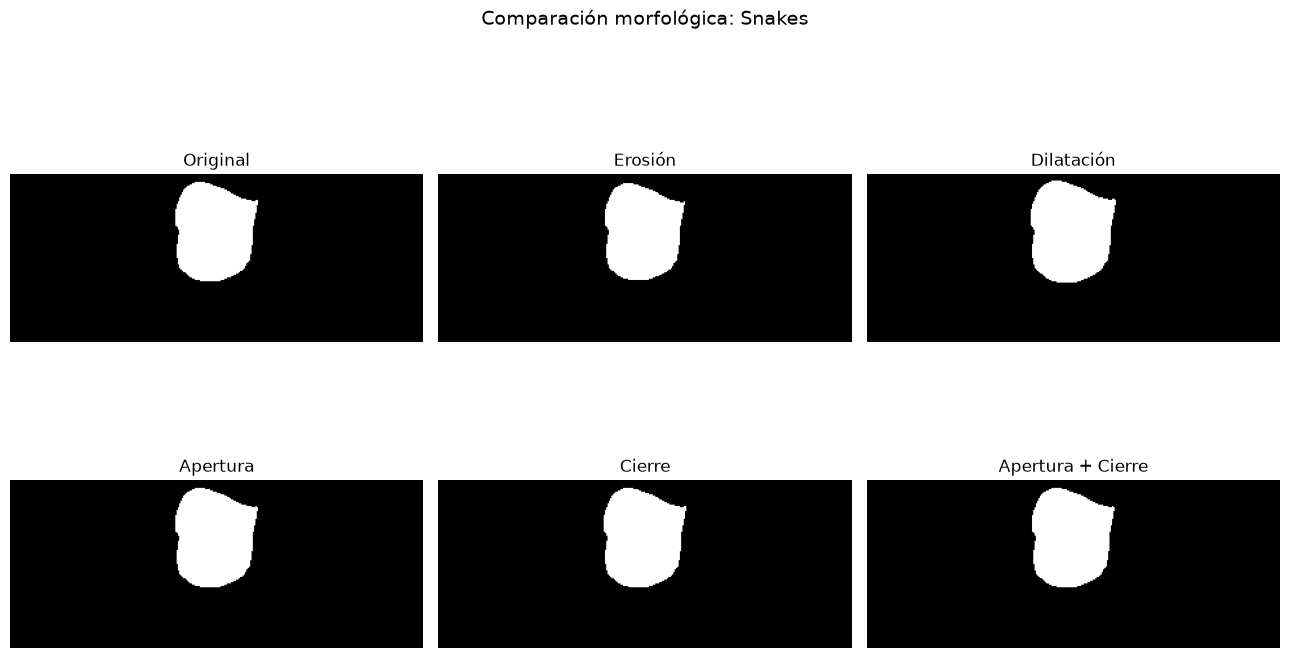

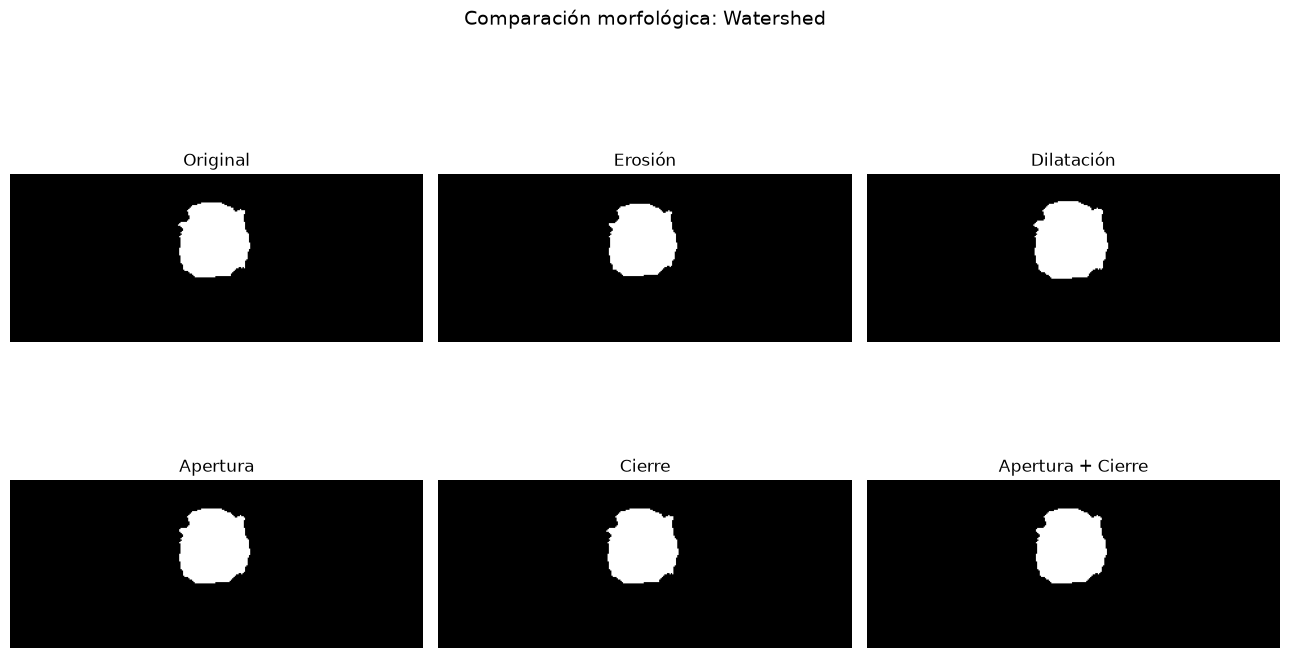

In [ ]:

for nombre, mascara in mascaras_originales.items():

    variantes = {
        "Original": mascaras_comparacion[f"{nombre} - Original"],
        "Erosión": mascaras_comparacion[f"{nombre} - Erosión"],
        "Dilatación": mascaras_comparacion[f"{nombre} - Dilatación"],
        "Apertura": mascaras_comparacion[f"{nombre} - Apertura"],
        "Cierre": mascaras_comparacion[f"{nombre} - Cierre"],
        "Apertura + Cierre": mascaras_comparacion[
            f"{nombre} - Apertura + Cierre"
        ]
    }

    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    for ax, (operacion, resultado) in zip(
        axes.flat, variantes.items()
    ):
        ax.imshow(resultado, cmap="gray", vmin=0, vmax=255)
        ax.set_title(operacion)
        ax.axis("off")

    fig.suptitle(
        f"Comparación morfológica: {nombre}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

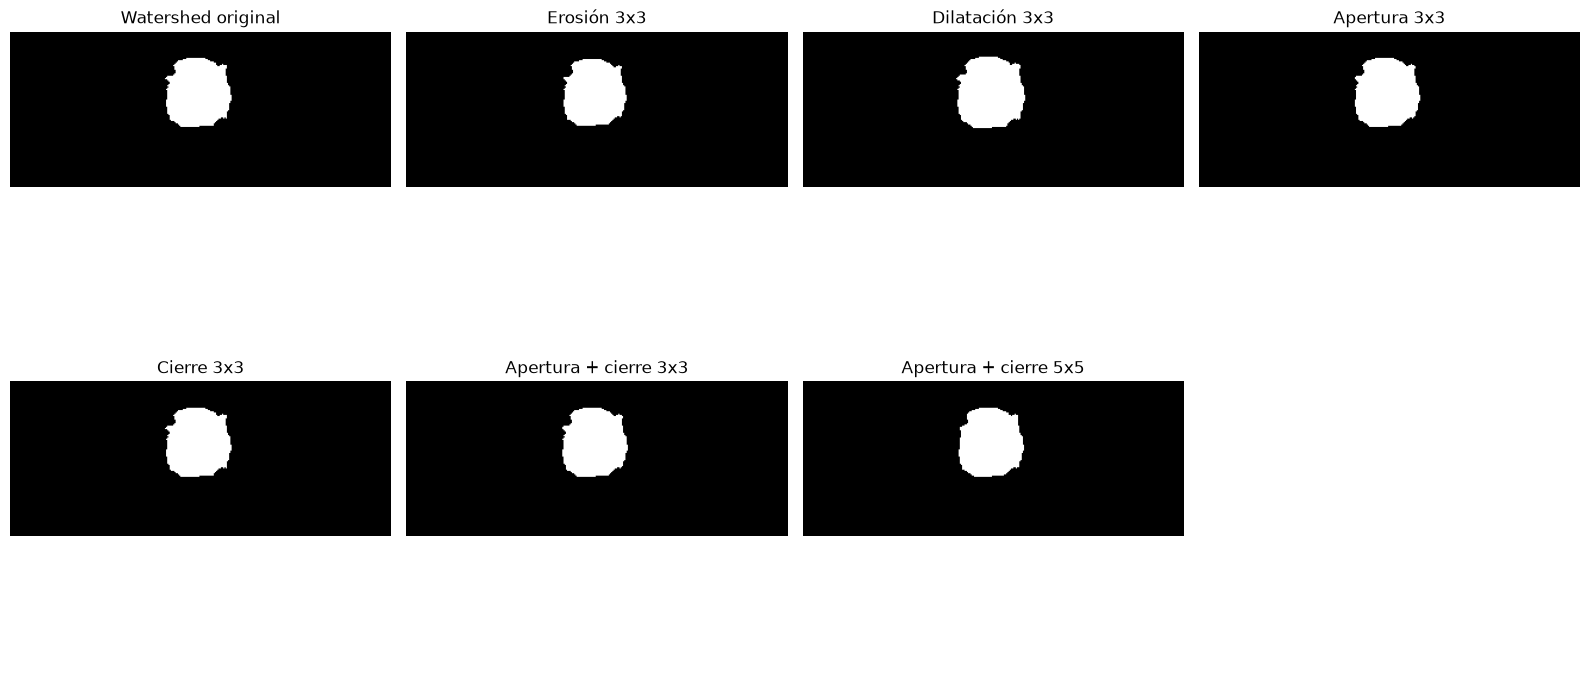

In [61]:
# Operaciones morfológicas sobre la máscara de Watershed
kernel_3 = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, (3, 3)
)

kernel_5 = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE, (5, 5)
)

mascaras = {
    "Watershed original": mask_watershed.copy(),

    "Erosión 3x3": cv2.erode(
        mask_watershed, kernel_3, iterations=1
    ),

    "Dilatación 3x3": cv2.dilate(
        mask_watershed, kernel_3, iterations=1
    ),

    "Apertura 3x3": cv2.morphologyEx(
        mask_watershed, cv2.MORPH_OPEN, kernel_3
    ),

    "Cierre 3x3": cv2.morphologyEx(
        mask_watershed, cv2.MORPH_CLOSE, kernel_3
    ),

    "Apertura + cierre 3x3": cv2.morphologyEx(
        cv2.morphologyEx(
            mask_watershed, cv2.MORPH_OPEN, kernel_3
        ),
        cv2.MORPH_CLOSE, kernel_3
    ),

    "Apertura + cierre 5x5": cv2.morphologyEx(
        cv2.morphologyEx(
            mask_watershed, cv2.MORPH_OPEN, kernel_5
        ),
        cv2.MORPH_CLOSE, kernel_5
    )
}

# Comparación visual de las máscaras
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (nombre, mascara) in zip(axes.flat, mascaras.items()):
    ax.imshow(mascara, cmap="gray", vmin=0, vmax=255)
    ax.set_title(nombre)
    ax.axis("off")

# Ocultar el espacio sobrante
for ax in axes.flat[len(mascaras):]:
    ax.axis("off")

plt.tight_layout()
plt.show()